In [1]:
from neuromaps import NeuroMapManuscript

model = NeuroMapManuscript.load("checkpoints/model.ckpt")

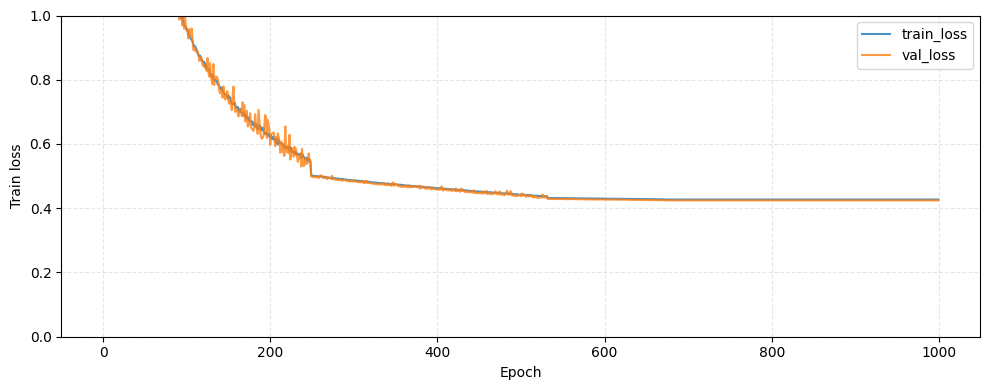

In [2]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np

plt.style.use('default')
mpl.rcdefaults()

hist = model.training_history

fig, ax = plt.subplots(1, 1, figsize=(10, 4))

ax.plot(np.arange(len(hist["train_loss"])), hist["train_loss"],
        label="train_loss", lw=1.5, alpha=.8)
ax.plot(np.arange(len(hist["val_loss"])), hist["val_loss"],
        label="val_loss", lw=1.5, alpha=.8)

ax.set_xlabel(f"Epoch")
ax.set_ylabel("Train loss")
ax.set_ylim([0, 1])
ax.legend()
ax.grid(True, ls="--", alpha=.3)
plt.tight_layout()
plt.show()

Симуляция: 100%|██████████████████████████████████████████| 20000/20000 [00:00<00:00, 28345.07шаг/s]


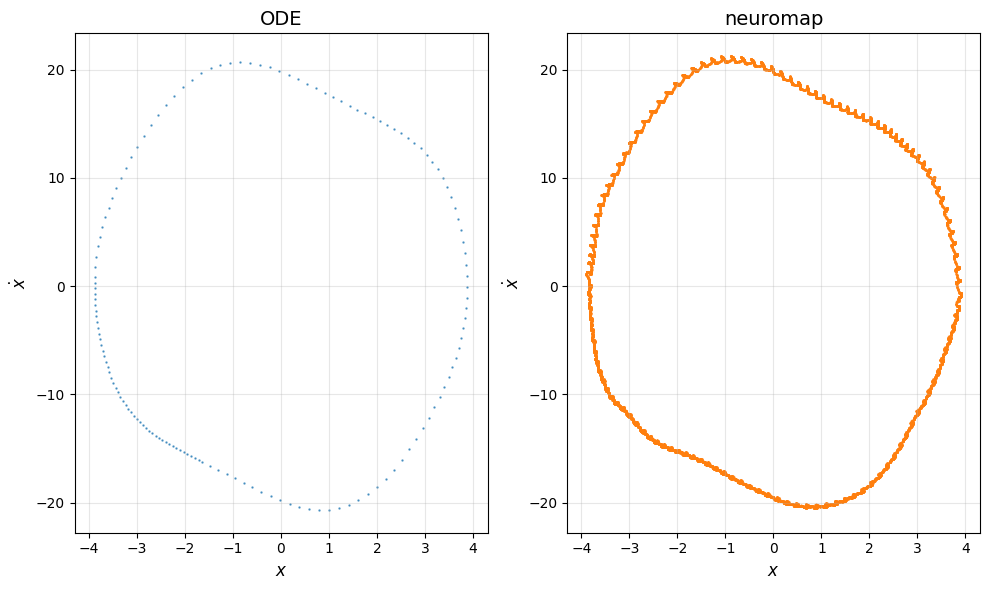

In [3]:
from utils import plot_compare_trajectories, get_attractor_trajectory
from systems import vdp_mod1_rk4, vdp_mod1_right_part

u0 = [5, -50]
p = [-1.78, 0.07]

ode_traj = get_attractor_trajectory(vdp_mod1_rk4, vdp_mod1_right_part, 
                                    u0, p, 0.01, 300, 200, lambda x, y: x[1],
                                    lambda x, y: [0, 1], divergence_threshold=1e3)
nm_traj = model.simulate(u0=u0, p=p, n_steps=20000, divergence_threshold=1e3)

if nm_traj is not None:
    nm_traj = nm_traj[1000:]
if ode_traj is not None:
    ode_traj = ode_traj[100:]

plot_compare_trajectories(ode_traj, nm_traj, labels=['ODE', 'neuromap'], layout='sidebyside')

In [26]:
from utils import grid_of_amplitude_basin_over_initial_state
from systems import vdp_mod1_rk4
import numpy as np

p_fixed = [-1.0, 0.07]
u0_base = [0.0, 0.0]
dt = 0.01
divergence_threshold = 1e5

x_grid = np.linspace(-10, 10, 100)
y_grid = np.linspace(-135, 135, 100)
x_state_index, y_state_index = 0, 1

Z_ode, div_ode = grid_of_amplitude_basin_over_initial_state(
    evolution_operator=vdp_mod1_rk4,
    state=u0_base,
    params=p_fixed,
    dt=dt,
    n_transient=300,
    n_attractor=200,
    x_grid=x_grid,
    y_grid=y_grid,
    x_state_index=x_state_index,
    y_state_index=y_state_index,
    divergence_threshold=divergence_threshold,
    ode_amplitude_mode="secant",
    secant_plane=lambda x, y: x[1],
    secant_plane_derivatives=lambda x, y: [0, 1],
    right_part=vdp_mod1_right_part
)

Z_nm, div_nm = grid_of_amplitude_basin_over_initial_state(
    evolution_operator=vdp_mod1_rk4,
    state=u0_base,
    params=p_fixed,
    dt=dt,
    n_transient=5000,
    n_attractor=5000,
    x_grid=x_grid,
    y_grid=y_grid,
    x_state_index=x_state_index,
    y_state_index=y_state_index,
    model=model,
    divergence_threshold=divergence_threshold,
)

Сетка по u0 (ODE, секущая): амплитуда + расходимость: 100%|██████████| 100/100 [27:44<00:00, 16.64s/it]
Сетка по u0 (Neuromap): амплитуда + расходимость:   0%|          | 0/100 [00:00<?, ?it/s]/Users/apanyushev/neuromap_sync/venv/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
Сетка по u0 (Neuromap): амплитуда + расходимость: 100%|██████████| 100/100 [21:55<00:00, 13.15s/it] 


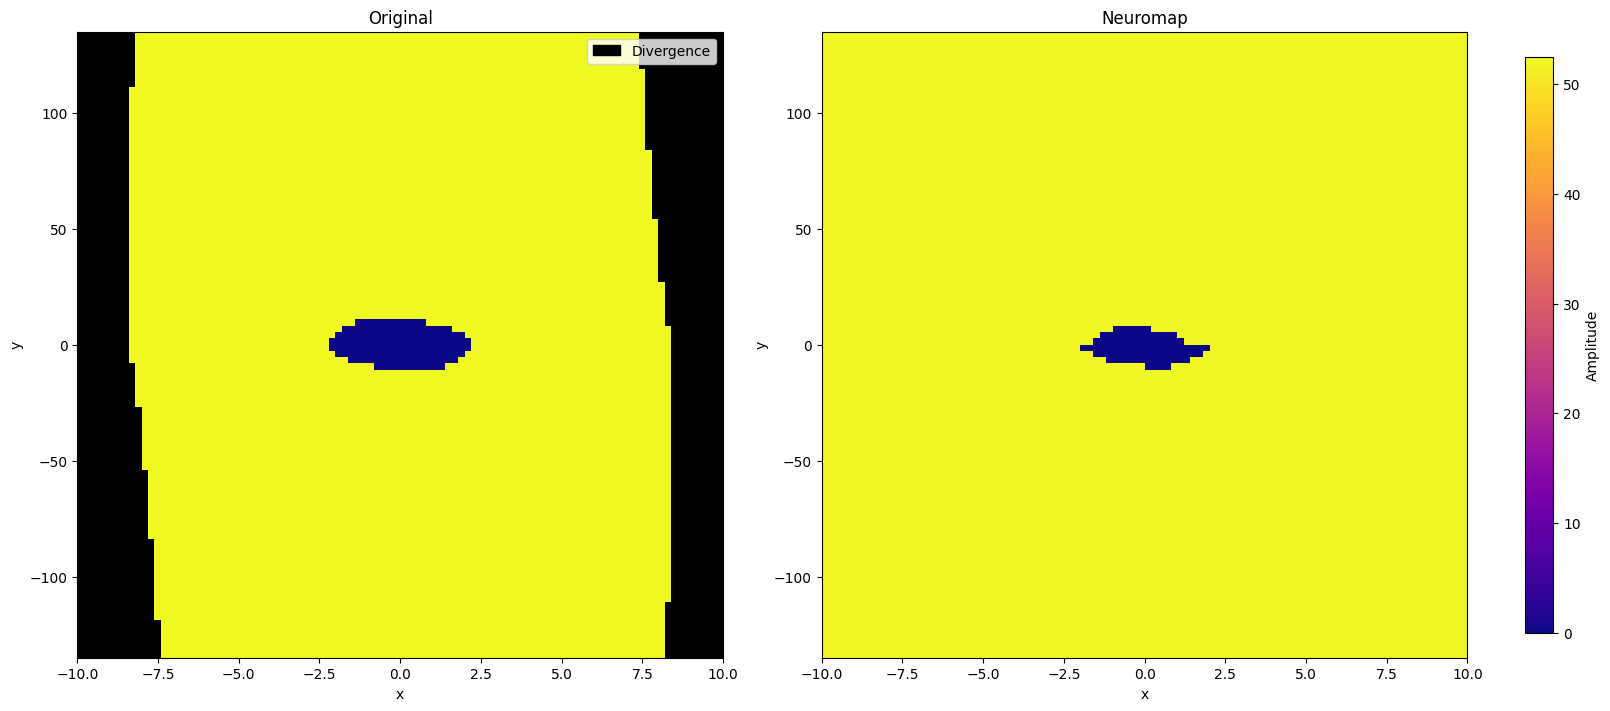

In [27]:
from utils import plot_amplitude_basin, plot_compare_amplitude_basins

plot_compare_amplitude_basins(
    x_grid,
    y_grid,
    Z_ode,
    Z_nm,
    x_label='x',
    y_label='y',
    cmap='plasma',
    bad_color='black',
)

Симуляция: 100%|██████████████████████████████████████████| 20000/20000 [00:00<00:00, 28377.58шаг/s]

2026-03-21 21:29:48 - neuromap_sync.plots - INFO - _plot_2d_trajectories:497 - ODE: divergence


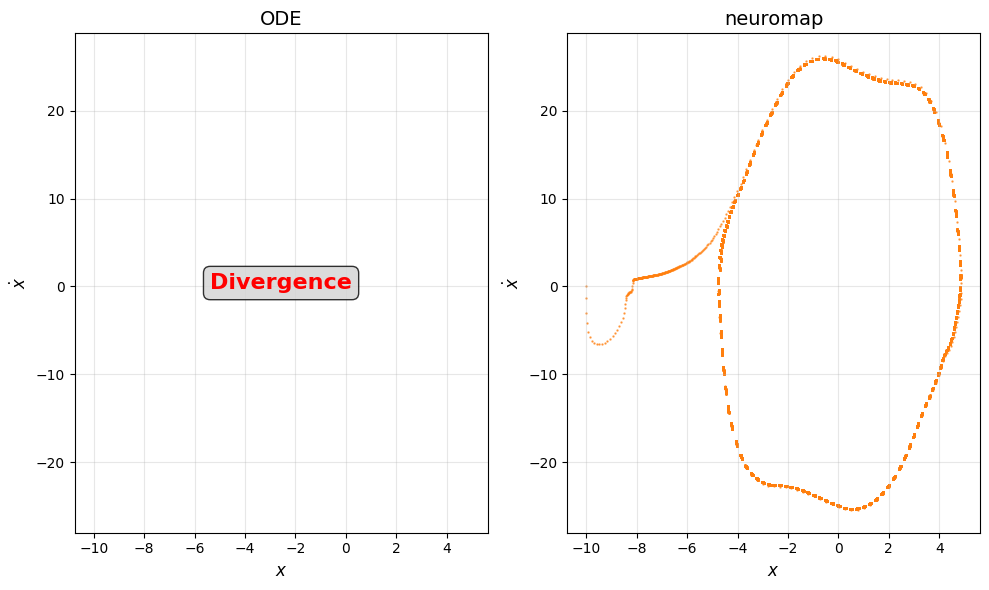

In [28]:
from utils import plot_compare_trajectories, get_attractor_trajectory
from systems import vdp_mod1_rk4, vdp_mod1_right_part

u0 = [-10.0, 0.0]
p = [-1.0, 0.07]

ode_traj = get_attractor_trajectory(vdp_mod1_rk4, vdp_mod1_right_part, 
                                    u0, p, 0.01, 300, 200, lambda x, y: x[1],
                                    lambda x, y: [0, 1], divergence_threshold=1e3)
nm_traj = model.simulate(u0=u0, p=p, n_steps=20000, divergence_threshold=1e3)

plot_compare_trajectories(ode_traj, nm_traj, labels=['ODE', 'neuromap'], layout='sidebyside')